# OpenStreetMap quickstart — current-state features (Overpass)

This notebook teaches the **Overpass** half of the `earthlens.osm` backend: how to pull
**current-state** OpenStreetMap features for a small area and work with the result. By the
end you will be able to run a named query, read the returned
[`FeatureCollection`](https://serapeum-org.github.io/earthlens/), and map it.

`earthlens.osm` is a **vector** backend: `download()` returns a pyramids `FeatureCollection`
(a `geopandas.GeoDataFrame` subclass, CRS `EPSG:4326`) and also writes one file. OSM data is
**ODbL** (share-alike), so every download emits a `LicenseWarning` — credit
'© OpenStreetMap contributors' when you redistribute.


## Setup

The imports for the whole notebook. `EarthLens` is the unified entry point; `matplotlib`
draws the maps. We also pick a small output directory — keep OSM bboxes small, the public
Overpass service is shared infrastructure.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
from earthlens.core import EarthLens

OUT_DIR = Path('osm_output')
OUT_DIR.mkdir(exist_ok=True)

!!! note
    The public Overpass API allows only **2 concurrent slots** per client. This notebook runs
    several queries, so we pause briefly (`time.sleep`) between them to stay a good citizen of
    the shared service — bursting would earn an HTTP 429.

### The area of interest

A tiny bounding box over central Heidelberg, Germany — dense, well-mapped OSM coverage so the
queries return features quickly. The box is `lat_lim` / `lon_lim` in degrees (WGS84).

| argument | meaning | value here |
|---|---|---|
| `lat_lim` | `[south, north]` | `[49.40, 49.42]` |
| `lon_lim` | `[west, east]` | `[8.67, 8.71]` |

In [2]:
LAT_LIM = [49.40, 49.42]
LON_LIM = [8.67, 8.71]

## Quickstart — hospitals as a FeatureCollection

The shortest end-to-end example: pick the `overpass:hospitals` **named query** via
`variables=`, give it the bbox, and `download()`. The backend builds the Overpass QL, runs
the live query, and returns the features. (The `LicenseWarning` you see is the ODbL notice —
expected on every result.)

In [3]:
hospitals = EarthLens(
    data_source='osm',
    variables=['overpass:hospitals'],
    lat_lim=LAT_LIM,
    lon_lim=LON_LIM,
    path=str(OUT_DIR),
).download()

len(hospitals), type(hospitals).__name__

2026-06-28 18:16:30 | INFO | pyramids.base.config | Logging is configured.


2026-06-28 18:16:32.251 | INFO     | earthlens.osm.backend:_fetch_overpass:424 - Querying Overpass for 'overpass:hospitals' over bbox (49.4,8.67,49.42,8.71)


2026-06-28 18:16:37.823 | INFO     | earthlens.osm.backend:_fetch:381 - overpass:hospitals: fetched 9 feature(s)


C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm\src\earthlens\earthlens.py:1693: LicenseWarning: OpenStreetMap data is licensed under the Open Database License (ODbL 1.0), which carries attribution and share-alike obligations: credit '(c) OpenStreetMap contributors' and license any derived database under ODbL when redistributing.
  return self.datasource.download(*args, progress_bar=progress_bar, **kwargs)
2026-06-28 18:16:37 | INFO | pyogrio._io | Created 9 records


2026-06-28 18:16:37.889 | INFO     | earthlens.osm.backend:download:552 - OSM download summary: 9 feature(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm\docs\examples\osm\osm_output\osm_overpass-hospitals.geojson


(9, 'FeatureCollection')

Each row is one OSM element. The `osm_id` / `osm_type` columns identify it, the element's OSM
tags ride as their own columns, and `geometry` is a shapely `Point` (a node) or `Polygon` (a
building footprint). Let's peek at a few identifying columns.

In [4]:
cols = [
    c
    for c in ['osm_id', 'osm_type', 'amenity', 'name', 'geometry']
    if c in hospitals.columns
]
hospitals[cols].head()

,osm_id,osm_type,amenity,name,geometry
0,35842577,way,hospital,NaN,"POLYGON ((8.69 49.40905, 8.68996 49.40904, 8.6..."
1,96690377,way,hospital,Unfallchirurgie - ATOS,"POLYGON ((8.69087 49.41032, 8.691 49.41033, 8...."
2,140128817,way,hospital,Institut für Psychosomatische Kooperationsfors...,"POLYGON ((8.68634 49.4082, 8.68629 49.40819, 8..."
3,141216666,way,hospital,Tropenmedizinische Ambulanz / Heidelberg Insti...,"POLYGON ((8.66946 49.41605, 8.66948 49.41605, ..."
4,155203932,way,hospital,Kinder- & Jugendpsychiatrie Heidelberg,"POLYGON ((8.685 49.40876, 8.68498 49.40881, 8...."


### Map the result

A `FeatureCollection` is a GeoDataFrame, so `.plot()` maps it directly. Point and polygon
hospitals are coloured by their geometry type.

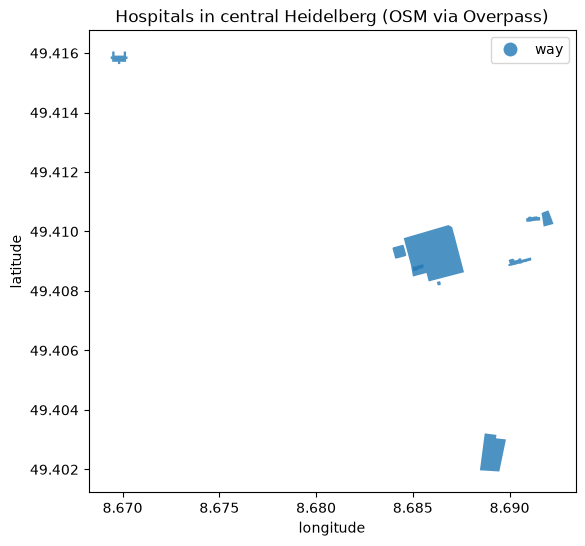

In [5]:
ax = hospitals.plot(
    column='osm_type',
    categorical=True,
    legend=True,
    markersize=40,
    alpha=0.8,
    figsize=(7, 6),
)
ax.set_title('Hospitals in central Heidelberg (OSM via Overpass)')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.show()

## Another named query — the road network

`overpass:roads` returns every `highway` way as a `LineString`. The named queries are listed
by `EarthLens.list_datasets('osm')`; the `<protocol>:` prefix selects Overpass vs ohsome.

In [6]:
EarthLens.list_datasets('osm')

['ohsome:amenities',
 'ohsome:buildings',
 'ohsome:highways',
 'overpass:buildings',
 'overpass:cafes',
 'overpass:hospitals',
 'overpass:roads',
 'overpass:schools']

2026-06-28 18:16:50.237 | INFO     | earthlens.osm.backend:_fetch_overpass:424 - Querying Overpass for 'overpass:roads' over bbox (49.4,8.67,49.42,8.71)


2026-06-28 18:16:51.705 | INFO     | earthlens.osm.backend:_fetch:381 - overpass:roads: fetched 5953 feature(s)


C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm\src\earthlens\earthlens.py:1693: LicenseWarning: OpenStreetMap data is licensed under the Open Database License (ODbL 1.0), which carries attribution and share-alike obligations: credit '(c) OpenStreetMap contributors' and license any derived database under ODbL when redistributing.
  return self.datasource.download(*args, progress_bar=progress_bar, **kwargs)


2026-06-28 18:16:54 | INFO | pyogrio._io | Created 5,953 records


2026-06-28 18:16:54.683 | INFO     | earthlens.osm.backend:download:552 - OSM download summary: 5953 feature(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm\docs\examples\osm\osm_output\osm_overpass-roads.geojson


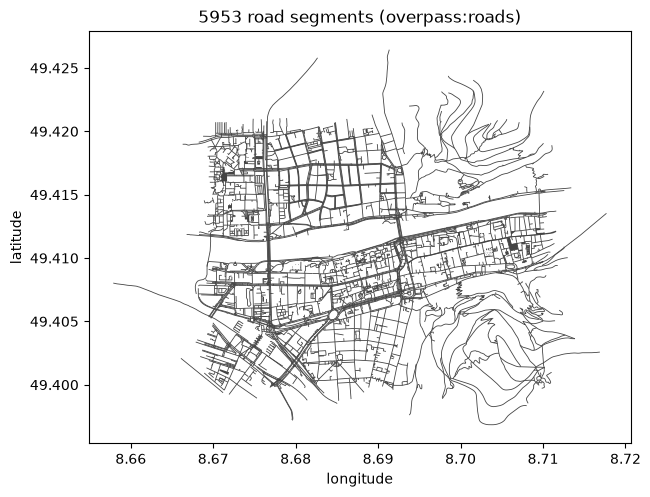

In [7]:
time.sleep(12)  # let the Overpass slots recover before the next query
roads = EarthLens(
    data_source='osm',
    variables=['overpass:roads'],
    lat_lim=LAT_LIM,
    lon_lim=LON_LIM,
    path=str(OUT_DIR),
).download()

ax = roads.plot(linewidth=0.6, color='#444', figsize=(7, 6))
ax.set_title(f'{len(roads)} road segments (overpass:roads)')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.show()

## Raw Overpass QL (power users)

When the named queries aren't enough, pass your own Overpass QL via `query=`. A `{bbox}`
placeholder is filled with the request bbox; the query must request JSON output
(`[out:json]`). Here we fetch museums (`tourism=museum`).

In [8]:
time.sleep(12)  # be gentle with the shared Overpass service
museums = EarthLens(
    data_source='osm',
    variables=['overpass:hospitals'],  # still required to route to Overpass
    lat_lim=LAT_LIM,
    lon_lim=LON_LIM,
    query='[out:json][timeout:180];(node["tourism"="museum"]({bbox}););out geom;',
    path=str(OUT_DIR),
).download()

museums[[c for c in ['osm_id', 'name', 'geometry'] if c in museums.columns]].head()

2026-06-28 18:17:07.339 | INFO     | earthlens.osm.backend:_fetch_overpass:424 - Querying Overpass for 'overpass:hospitals' over bbox (49.4,8.67,49.42,8.71)


2026-06-28 18:17:08.938 | INFO     | earthlens.osm.backend:_fetch:381 - overpass:hospitals: fetched 14 feature(s)


C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm\src\earthlens\earthlens.py:1693: LicenseWarning: OpenStreetMap data is licensed under the Open Database License (ODbL 1.0), which carries attribution and share-alike obligations: credit '(c) OpenStreetMap contributors' and license any derived database under ODbL when redistributing.
  return self.datasource.download(*args, progress_bar=progress_bar, **kwargs)
2026-06-28 18:17:08 | INFO | pyogrio._io | Created 14 records


2026-06-28 18:17:08.949 | INFO     | earthlens.osm.backend:download:552 - OSM download summary: 14 feature(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm\docs\examples\osm\osm_output\osm_overpass-hospitals.geojson


,osm_id,name,geometry
0,267889562,Kurpfälzisches Museum,POINT (8.7029 49.41137)
1,1300163591,Museum Geowissenschaften,POINT (8.67445 49.41902)
2,1324802486,Unimuseum,POINT (8.70669 49.41139)
3,1412648912,Zoologisches Museum,POINT (8.67431 49.41786)
4,2421161970,Körperwelten,POINT (8.68872 49.40798)


## Takeaway

- `EarthLens('osm', variables=['overpass:<query>'], lat_lim=…, lon_lim=…).download()` returns a
  `FeatureCollection` of current-state OSM features.
- Named queries cover the common cases; a raw `query=` (JSON output) is the escape hatch.
- Keep the bbox small, and honour the **ODbL** attribution / share-alike obligation.

Next: `ohsome_history.ipynb` shows the **history-aware** ohsome protocol.